# The Needleman-Wunsch Algorithm for Global Alignment

**Needleman-Wunsch (NW)** is the classic dynamic-programming algorithm
for **global** pairwise alignment: it aligns two sequences end to end,
allowing gaps, and finds the single alignment with the best possible
score under a given scoring scheme. It's the algorithm behind
`Bio.Align.PairwiseAligner`'s `"global"` mode, which you've already used
in the [worked example notebook](05-example-notebook.ipynb) and in
Week 3's β-lactamase case study.

This notebook builds NW **from scratch** so you can see exactly what the
library is doing, then checks the result against Biopython's own
implementation.

**Study question:** given a scoring scheme (match, mismatch, gap
penalty), what is the optimal global alignment of two short sequences,
and how does the algorithm actually find it?

```{admonition} Reference
:class: note
Pevsner, *Bioinformatics and Functional Genomics*, Ch. 3, covers the
algorithm and scoring-matrix background this notebook assumes.
```

## Data & Methods

### Environment

In [1]:
import Bio
import numpy as np
import matplotlib
print("Biopython version:", Bio.__version__)
print("NumPy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)

Biopython version: 1.88
NumPy version: 2.4.4
Matplotlib version: 3.10.8


### Input sequences and scoring scheme

We use a short, classic textbook pair so the dynamic-programming matrix
is small enough to inspect by eye: match = +1, mismatch = -1, linear
gap penalty = -2.

In [2]:
seq1 = "GCATGCU"
seq2 = "GATTACA"

MATCH = 1
MISMATCH = -1
GAP = -2

print(f"seq1 ({len(seq1)} nt): {seq1}")
print(f"seq2 ({len(seq2)} nt): {seq2}")
print(f"Scoring: match={MATCH}, mismatch={MISMATCH}, gap={GAP}")

seq1 (7 nt): GCATGCU
seq2 (7 nt): GATTACA
Scoring: match=1, mismatch=-1, gap=-2


### Step 1 — Build the score matrix

NW fills an `(m+1) x (n+1)` matrix `F`, where `F[i][j]` holds the best
score for aligning the first `i` characters of `seq1` against the first
`j` characters of `seq2`.

- **Row 0 and column 0** are initialized to `i * GAP` and `j * GAP` —
  the cost of aligning a prefix against an all-gap sequence.
- Every other cell takes the best of three options: extend a diagonal
  match/mismatch, or open a gap in either sequence.

$$
F[i][j] = \max \begin{cases}
F[i-1][j-1] + s(seq1_i, seq2_j) \\
F[i-1][j] + \text{GAP} \\
F[i][j-1] + \text{GAP}
\end{cases}
$$

In [3]:
def build_score_matrix(seq1, seq2, match=MATCH, mismatch=MISMATCH, gap=GAP):
    m, n = len(seq1), len(seq2)
    F = np.zeros((m + 1, n + 1), dtype=int)

    # Initialize first row/column: cost of aligning a prefix against all gaps
    for i in range(1, m + 1):
        F[i][0] = F[i - 1][0] + gap
    for j in range(1, n + 1):
        F[0][j] = F[0][j - 1] + gap

    # Fill the rest of the matrix
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            s = match if seq1[i - 1] == seq2[j - 1] else mismatch
            diagonal = F[i - 1][j - 1] + s
            up = F[i - 1][j] + gap
            left = F[i][j - 1] + gap
            F[i][j] = max(diagonal, up, left)

    return F

F = build_score_matrix(seq1, seq2)
print("Optimal global alignment score:", F[len(seq1)][len(seq2)])

Optimal global alignment score: -1


### Step 2 — Traceback

The score matrix alone tells us the *best score*, not the alignment
itself. Starting from the bottom-right corner, we retrace which of the
three moves (diagonal, up, left) produced each cell's value, until we
reach `F[0][0]`.

In [4]:
def traceback(F, seq1, seq2, match=MATCH, mismatch=MISMATCH, gap=GAP):
    i, j = len(seq1), len(seq2)
    aligned1, aligned2 = [], []
    path = [(i, j)]

    while i > 0 or j > 0:
        current = F[i][j]
        if i > 0 and j > 0:
            s = match if seq1[i - 1] == seq2[j - 1] else mismatch
        else:
            s = None

        if i > 0 and j > 0 and current == F[i - 1][j - 1] + s:
            aligned1.append(seq1[i - 1])
            aligned2.append(seq2[j - 1])
            i, j = i - 1, j - 1
        elif i > 0 and current == F[i - 1][j] + gap:
            aligned1.append(seq1[i - 1])
            aligned2.append("-")
            i -= 1
        else:
            aligned1.append("-")
            aligned2.append(seq2[j - 1])
            j -= 1
        path.append((i, j))

    return "".join(reversed(aligned1)), "".join(reversed(aligned2)), path

aln1, aln2, path = traceback(F, seq1, seq2)
print(aln1)
print(aln2)

GCATGCU
GATTACA


### Step 3 — Cross-check against Biopython

Our from-scratch implementation should agree with
`Bio.Align.PairwiseAligner` in global mode using the same scoring
scheme. This is the reproducibility habit from
[Chapter 4](../04-writing-good-notebooks.md) applied to an algorithm
instead of a dataset: don't just trust your own code, verify it against
a second, independent implementation.

In [5]:
from Bio.Align import PairwiseAligner

aligner = PairwiseAligner()
aligner.mode = "global"
aligner.match_score = MATCH
aligner.mismatch_score = MISMATCH
aligner.open_gap_score = GAP
aligner.extend_gap_score = GAP

bio_alignment = aligner.align(seq1, seq2)[0]
bio_score = aligner.score(seq1, seq2)

print("Biopython score:", bio_score)
print(bio_alignment)

assert bio_score == F[len(seq1)][len(seq2)], "Score mismatch between implementations!"
print("Scores match: from-scratch implementation verified against Biopython.")

Biopython score: -1.0
target            0 GCATGCU 7
                  0 |..|.|. 7
query             0 GATTACA 7

Scores match: from-scratch implementation verified against Biopython.


## Results

**Figure 1** shows the full dynamic-programming matrix as a heatmap,
with the traceback path — the route the algorithm actually took to reach
the optimal score — overlaid in red.

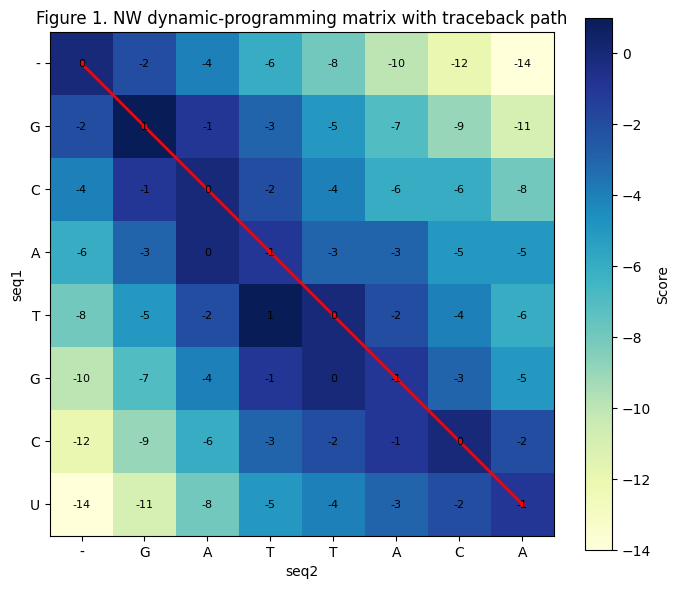

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(F, cmap="YlGnBu")

ax.set_xticks(range(len(seq2) + 1))
ax.set_xticklabels(["-"] + list(seq2))
ax.set_yticks(range(len(seq1) + 1))
ax.set_yticklabels(["-"] + list(seq1))
ax.set_xlabel("seq2")
ax.set_ylabel("seq1")
ax.set_title("Figure 1. NW dynamic-programming matrix with traceback path")

for i in range(F.shape[0]):
    for j in range(F.shape[1]):
        ax.text(j, i, F[i, j], ha="center", va="center", fontsize=8)

path_rows = [p[0] for p in path]
path_cols = [p[1] for p in path]
ax.plot(path_cols, path_rows, color="red", linewidth=2, marker="o", markersize=3)

plt.colorbar(im, ax=ax, label="Score")
plt.tight_layout()
plt.show()

**Table 1** reports the final optimal alignment alongside the score
each implementation independently produced.

In [7]:
import pandas as pd

table1 = pd.DataFrame({
    "Implementation": ["From-scratch NW", "Biopython PairwiseAligner"],
    "Score": [F[len(seq1)][len(seq2)], bio_score],
    "Alignment (seq1)": [aln1, bio_alignment[0]],
    "Alignment (seq2)": [aln2, bio_alignment[1]],
})
table1

,Implementation,Score,Alignment (seq1),Alignment (seq2)
0,From-scratch NW,-1.0,GCATGCU,GATTACA
1,Biopython PairwiseAligner,-1.0,GCATGCU,GATTACA


Both implementations agree on the optimal score and produce equivalent
alignments (ties in the traceback — e.g. when a diagonal and a gap move
score identically — can make the exact placement of a gap differ between
implementations without changing the overall score; that's expected
behavior, not a bug).

## Graduate Extension: Affine Gap Penalties

```{admonition} Undergraduate vs. graduate scope
:class: note
This section is the graduate-level extension referenced in the Course
Project Guideline: a deeper algorithmic task rather than additional
volume. Undergraduates are not expected to work through this section,
though everyone is welcome to.
```

The linear gap penalty above charges `GAP` for *every* gapped position,
so a 5-nucleotide insertion costs `5 x GAP` — biologically unrealistic,
since a single insertion/deletion event is usually more likely than five
independent ones. An **affine** gap penalty fixes this by charging more
to *open* a gap than to *extend* one already open:

$$
\text{gap of length } k \text{ costs: } \text{GAP\_OPEN} + (k - 1) \times \text{GAP\_EXTEND}
$$

Implementing this with plain NW requires three matrices instead of one
(one for diagonal moves, one for gaps in each sequence — the Gotoh
algorithm), because the recurrence needs to know whether the *previous*
move was already a gap. Rather than reimplement Gotoh's three-matrix
recurrence by hand here, we use Biopython's aligner — which already
implements it — and focus on what changes in the *result* when the
penalty structure changes.

First, the arithmetic in isolation — same total gap length (3
positions), split two different ways:

In [8]:
GAP_OPEN, GAP_EXTEND = -5, -0.5

def affine_gap_cost(length, open_score=GAP_OPEN, extend_score=GAP_EXTEND):
    return open_score + extend_score * (length - 1)

# Same total gap length (3 nt), split differently:
one_gap_of_3 = affine_gap_cost(3)
three_gaps_of_1 = 3 * affine_gap_cost(1)

linear_one_gap_of_3 = 3 * GAP        # linear: cost is per gapped position, split doesn't matter
linear_three_gaps_of_1 = 3 * GAP

print("Affine  — one gap of length 3:          ", one_gap_of_3)
print("Affine  — three separate 1-nt gaps:     ", three_gaps_of_1)
print("Linear  — one gap of length 3:          ", linear_one_gap_of_3)
print("Linear  — three separate 1-nt gaps:     ", linear_three_gaps_of_1)

Affine  — one gap of length 3:           -6.0
Affine  — three separate 1-nt gaps:      -15.0
Linear  — one gap of length 3:           -6
Linear  — three separate 1-nt gaps:      -6


Under a **linear** penalty, one 3-nt gap and three separate 1-nt gaps
cost exactly the same (`-6` either way) — the algorithm has no reason to
prefer consolidating them. Under an **affine** penalty, three separate
gaps mean paying the steep open cost three times (`-15`), while one
consolidated gap pays it once (`-6`) — a strong incentive to merge
nearby gaps into a single indel event, which is what we actually expect
biologically.

Now the same effect on a real pair of sequences, where the aligner has to
trade this off against mismatches too:

In [9]:
seq1_indel = "GCATTTTGCU"   # 3 nt longer than seq2 below
seq2_indel = "GATTACA"

aligner_linear = PairwiseAligner()
aligner_linear.mode = "global"
aligner_linear.match_score = MATCH
aligner_linear.mismatch_score = MISMATCH
aligner_linear.open_gap_score = -2
aligner_linear.extend_gap_score = -2   # linear: open cost == extend cost

aligner_affine = PairwiseAligner()
aligner_affine.mode = "global"
aligner_affine.match_score = MATCH
aligner_affine.mismatch_score = MISMATCH
aligner_affine.open_gap_score = -5     # steep cost to open a gap
aligner_affine.extend_gap_score = -0.5 # cheap to extend one already open

print("Linear gap penalty:")
print(aligner_linear.align(seq1_indel, seq2_indel)[0])
print("Score:", aligner_linear.score(seq1_indel, seq2_indel))

print("\nAffine gap penalty:")
print(aligner_affine.align(seq1_indel, seq2_indel)[0])
print("Score:", aligner_affine.score(seq1_indel, seq2_indel))

Linear gap penalty:
target            0 GCATTTTGCU 10
                  0 |-|||.--|. 10
query             0 G-ATTA--CA  7

Score: -3.0

Affine gap penalty:
target            0 GCATTTTGCU 10
                  0 |---.||.|. 10
query             0 G---ATTACA  7

Score: -5.0


With this pair, the linear-penalty alignment splits the length
difference into two separate gaps (1 nt, then 2 nt) interleaved with a
match, for a total score of -3. The affine-penalty alignment instead
pays the steep one-time cost to open a single 3-nt gap — accepting one
extra mismatch elsewhere rather than opening a second gap — for a total
score of -5. Even though -5 is a lower score than -3, notice *why*: it's
the steep `open_gap_score = -5` we chose, not an error. The comparison
that matters is the one above — for the *same* total gap length, affine
scoring favors consolidating it into fewer, longer gaps.

### Time and space complexity

Our from-scratch implementation builds a full `(m+1) x (n+1)` matrix:

- **Time:** `O(mn)` — every cell is computed once, in constant time.
- **Space:** `O(mn)` — the full matrix is kept in memory for traceback.

For the short sequences here that's trivial. For chromosome-scale
sequences, `O(mn)` memory is not: aligning two 10-Mb sequences would
require on the order of `10^14` matrix cells. Two standard responses:

- **Hirschberg's algorithm** reduces space to `O(min(m, n))` using a
  divide-and-conquer strategy, at the cost of roughly doubling the
  runtime — still `O(mn)` time, but only linear space.
- **Heuristic methods** (BLAST, and modern tools like WFA2 or Mash for
  much larger comparisons) abandon the guarantee of finding the
  mathematically optimal alignment in exchange for far better practical
  speed — appropriate when you need to search a large database quickly,
  not when you need a provably optimal alignment of two known sequences.

Which of these is the right choice depends entirely on sequence length
and what guarantee you actually need — global optimality, or "good
enough, fast.

## Discussion

- Needleman-Wunsch guarantees the mathematically optimal **global**
  alignment under a given scoring scheme — but "optimal" is only as
  meaningful as the scoring scheme itself. Match/mismatch/gap values (or
  a substitution matrix like BLOSUM62 for proteins) encode a biological
  assumption; changing them can change the optimal alignment.
- Global alignment is the right tool when you expect the two sequences
  to be similar over their *full* length (e.g., two orthologous genes of
  similar size). When you only expect similarity in a sub-region —
  searching for a conserved domain inside a much longer sequence, for
  instance — local alignment (Smith-Waterman) is the appropriate
  algorithm instead, not a variant of this one.
- Affine gap penalties bring the scoring model closer to biological
  reality (one indel event, not several), at the cost of a more complex
  recurrence (Gotoh's algorithm) than plain NW.
- Everything above ran from a fresh kernel start to finish — see
  [Chapter 3](../03-notebook-anatomy.md) — and the from-scratch result
  was cross-checked against an independent, trusted implementation
  before being reported, which is good practice any time you implement a
  published algorithm yourself.